# Introduction to Generative Models

<div class="nav-links">
  <a href="./intro.html">About Me</a>
  <a href="#">My Research</a>
  <a href="./intro.html#teaching">My Teaching</a>
  <a href="./research_notes/intro.html">Research Notes</a>
</div>

The tutorial starts with a general introduction to generative models. In this article, we will quickly go over the basic idea behind generative models, types of generative models. `Our main focus will be 

## Aim of Generative Models

The central goal of any **generative model** is to learn the underlying **data distribution** $p_{\text{data}}(x)$ from a finite dataset of samples $\{x^{(i)}\}_{i=1}^N$.  

Once we have a good approximation $p_\theta(x)$ (where $\theta$ are the model parameters), we can:

- **Generate new samples** $x \sim p_\theta(x)$ that look similar to the real data.
- **Evaluate likelihoods** $p_\theta(x)$ for given inputs (if the model allows it).
- **Learn useful latent representations** for downstream tasks.
- **Model uncertainty** and reason about missing or noisy data.

Formally, the training objective is usually to maximize the likelihood of the data under the model:

$$
\max_\theta \; \sum_{i=1}^N \log p_\theta(x^{(i)}).
$$

Different classes of generative models achieve this goal in different ways, depending on how they define, approximate, or bypass the likelihood.

## Types of Generative Models (from the tutorial)

The tutorial categorizes generative models into several families:

1. **Likelihood-based Models**
   - Directly maximize (or approximate) the likelihood of data.
   - Examples: Autoregressive models, Variational Autoencoders (VAEs), Normalizing Flows.

2. **Energy-Based Models (EBMs)**
   - Define an unnormalized energy function $E_\theta(x)$ such that
     
     $$
     p_\theta(x) = \frac{e^{-E_\theta(x)}}{Z(\theta)},
     $$
     
     where $Z(\theta)$ is the partition function.
     
   - Training usually relies on contrastive divergence or score matching.

3. **Variational Autoencoders (VAEs)**

   - Latent-variable models that approximate intractable posteriors via variational inference.
   - Optimize the **Evidence Lower Bound (ELBO)** instead of exact likelihood.

5. **Normalizing Flows**

   - Learn an **invertible transformation** between data $x$ and a simple base distribution $z \sim p(z)$.
   - Allow exact computation of log-likelihood using the change-of-variables formula.

7. **Score-Based Models**
   - Learn the **score function** $\nabla_x \log p(x)$ directly.
   - Sampling is performed via **stochastic differential equations (SDEs)** or **Langevin dynamics**.

8. **Generative Adversarial Networks (GANs)** *(briefly mentioned for context)*

   - Adversarially train a generator against a discriminator.
   - Do not provide explicit likelihoods, but excel at sharp sample generation.


## Focus of This Tutorial

In this tutorial, our **main focus will be on likelihood-based generative models**, since diffusion models themselves can be interpreted as a special case of these models (via the ELBO and variational inference perspective).

We will:

- **Dive deeply into likelihood-based approaches** such as autoregressive models, variational autoencoders (VAEs), and normalizing flows.
- Show how diffusion models emerge naturally from this family.
- Discuss the mathematical formulations and training objectives at length.

## Other Models (for completeness. This is optional.)

To place likelihood-based models in context, we will also **briefly discuss** other important families of generative models:

- **Energy-Based Models (EBMs):** Learn an energy landscape where data lies in low-energy valleys, trained via contrastive divergence.
- **Score-Based Models:** Learn the score function $\nabla_x \log p(x)$ and generate samples via stochastic differential equations.
- **Generative Adversarial Networks (GANs):** Adversarially train a generator and discriminator, excelling at sample quality but without tractable likelihoods.

For these models, I used LLM to provide **concise PyTorch implementations** to illustrate their training and sampling procedures, but our detailed mathematical discussion will remain centered on likelihood-based methods.

# Energy-Based Models (EBMs): A Complete, Practical Guide

## 1) What is an Energy-Based Model?

An **Energy-Based Model (EBM)** defines a **scalar energy** function $E_\theta(\mathbf{x})$ over inputs $\mathbf{x}\in\mathbb{R}^d$.  
The key idea: **low energy ↔ high probability, high energy ↔ low probability.**

Formally:

$$
p_\theta(\mathbf{x}) \;=\; \frac{\exp\!\big(-E_\theta(\mathbf{x})\big)}{Z(\theta)},
\qquad
Z(\theta) \;=\; \int \exp\!\big(-E_\theta(\mathbf{x})\big)\,d\mathbf{x}.
$$

- **Why exponential?** Because it ensures non-negativity of probabilities (since $\exp(z)\geq 0$).  
- **Why partition function $Z(\theta)$?** It normalizes the distribution so that $\int p_\theta(\mathbf{x})\,dx = 1$. Without $Z(\theta)$, we’d only have relative scores.  

👉 This is the same construction as the **Boltzmann distribution** in statistical physics, where states with lower energy are exponentially more likely.

- **What is learned?** The parameters $\theta$ of the energy network (e.g. an MLP or CNN).  
- **What is predicted?** Not a direct label or pixel value — instead, the model defines a **landscape of probabilities**. We can draw samples via **MCMC** (e.g. Langevin dynamics), or compare relative energies for tasks like classification.  

📖 Classical overview: [*A Tutorial on Energy-Based Learning* (LeCun et al., 2006)](https://web.stanford.edu/class/cs379c/archive/2012/suggested_reading_list/documents/LeCunetal06.pdf?utm_source=chatgpt.com).

## 2) Maximum Likelihood and the Partition Function

Suppose we want to maximize the likelihood of data $\{\mathbf{x}^{(i)}\}_{i=1}^N \sim p_{\text{data}}$:

$$
\max_\theta \ \frac{1}{N}\sum_{i=1}^N \log p_\theta(\mathbf{x}^{(i)})
= \max_\theta \ \mathbb{E}_{\mathbf{x}\sim p_{\text{data}}}\big[-E_\theta(\mathbf{x})\big] \;-\; \log Z(\theta).
$$

- The first term $-E_\theta(\mathbf{x})$ encourages the model to assign **low energy to real data**.  
- The second term $-\log Z(\theta)$ ensures global normalization — this is what makes training difficult, since $Z(\theta)$ is an **intractable integral** in high dimensions.

The gradient of the log-likelihood is:

$$
\nabla_\theta \log p_\theta(\mathbf{x})
= -\nabla_\theta E_\theta(\mathbf{x})
+ \mathbb{E}_{\mathbf{x}'\sim p_\theta}\big[\nabla_\theta E_\theta(\mathbf{x}')\big].
$$

Interpretation:
- **Positive phase**: lower $E_\theta$ on data.  
- **Negative phase**: raise $E_\theta$ on model samples.  

This **push-pull dynamic** shapes the energy surface: valleys form around the data manifold, hills elsewhere.

## 3) Why Partition Function $Z(\theta)$ Matters

The partition function

$$
Z(\theta) = \int \exp\!\big(-E_\theta(\mathbf{x})\big)\, dx
$$

is the normalizing constant.

- **Why is it needed?** To ensure $p_\theta(x)$ integrates to 1.  
- **Why is it hard?** For high-dimensional $x$ (e.g. 64×64 images), computing this integral exactly is intractable.  
- **Workaround:** Instead of computing $Z(\theta)$ directly, EBMs approximate the *negative phase* using MCMC-based samples.

👉 Intuition: $\exp(-E_\theta(x))$ gives **relative weights**, $Z(\theta)$ is the total “mass,” and dividing makes them probabilities.

## 4) Sampling: Langevin Dynamics & SGLD

To train EBMs, we need samples $\mathbf{x}' \sim p_\theta$. Since we can’t sample directly (due to $Z(\theta)$), we use **MCMC**.  

**Langevin dynamics** is the workhorse:

$$
\mathbf{x} \;\leftarrow\; \mathbf{x} - \tfrac{\alpha}{2}\,\nabla_\mathbf{x} E_\theta(\mathbf{x}) + \sqrt{\alpha}\,\boldsymbol{\xi},
\qquad \boldsymbol{\xi}\sim \mathcal{N}(0, I).
$$

- The **gradient term** $\nabla_\mathbf{x} E_\theta(x)$ moves $x$ downhill toward low-energy regions.  
- The **noise term** prevents collapse and ensures proper exploration.  
- Over many steps, the stationary distribution is exactly $p_\theta(x) \propto e^{-E_\theta(x)}$.  

👉 Design choice: we use **noise + gradient** instead of gradient descent alone because we want **sampling**, not just MAP estimation.

**SGLD (Stochastic Gradient Langevin Dynamics)** ([Welling & Teh, 2011](https://www.stats.ox.ac.uk/~teh/research/compstats/WelTeh2011a.pdf?utm_source=chatgpt.com)) combines Langevin with minibatch gradients, making it scalable to large datasets.

## 5) Contrastive Divergence (CD) & Persistent CD (PCD)

Computing the negative phase exactly is impossible. Instead:

- **Contrastive Divergence (CD-$k$)** ([Hinton, 2002](https://direct.mit.edu/neco/article/14/8/1771/6687/Training-Products-of-Experts-by-Minimizing?utm_source=chatgpt.com)) starts chains at real data and runs $k$ MCMC steps.  
- **Persistent CD (PCD)** keeps chains alive across training iterations using a **replay buffer**.  

Why?
- CD-$k$ mixes too slowly if $k$ is small.  
- PCD improves mixing because the buffer chains remember past states.  

Practical training objective:

$$
\min_\theta \; \mathbb{E}[E_\theta(x_{\text{pos}})] \;-\; \mathbb{E}[E_\theta(x_{\text{neg}})] \;+\; \lambda \cdot \text{regularizers}.
$$

## 6) Score-Matching View

Another lens:  
Since

$$
\nabla_x \log p_\theta(x) = -\nabla_x E_\theta(x),
$$

EBMs can also be learned by **matching scores** instead of likelihood.  
Hyvärinen’s **score matching** ([JMLR 2005](https://jmlr.org/papers/volume6/hyvarinen05a/hyvarinen05a.pdf?utm_source=chatgpt.com)) avoids computing $Z(\theta)$ entirely by aligning score fields.  

👉 This view leads directly into **denoising score matching** and **diffusion models** (Song & Ermon, 2019).

## 7) Modern EBMs in Practice

- **EBM Generation**: [Du & Mordatch, 2019 (arXiv)](https://arxiv.org/abs/1903.08689?utm_source=chatgpt.com) show that with PCD + Langevin, EBMs can generate realistic images.  
- **EBM Classifiers**: [Grathwohl et al., 2020 (arXiv)](https://arxiv.org/abs/1912.03263?utm_source=chatgpt.com) reinterpret classifiers as joint EBMs $p(x, y) \propto e^{-E(x, y)}$, improving OOD detection.  
- **Design choices in practice**:
  - Add small $L_2$ penalty on energies → prevents divergence.  
  - Tune step size/noise in Langevin → balance exploration vs convergence.  
  - Use replay buffers → stabilizes learning and avoids “forgetting.”

## 8) Training Algorithm We’ll Implement (Swiss-Roll Demo)

We’ll train an MLP $E_\theta(x)$ on a **Swiss-Roll spiral dataset**:

1. **Positive phase**: push down energy of real data.  
2. **Negative phase**: push up energy of generated samples.  
3. **Replay buffer + Langevin sampling** for efficient negatives.  

What you’ll see:
- Loss curves ($\text{loss}, e_{\text{pos}}, e_{\text{neg}}$).  
- Energy landscapes $E_\theta(x)$ evolving during training.  
- Generated samples clustering along the data manifold.  

👉 Intuition: At convergence, the energy surface has **valleys** along the Swiss roll, and generated negatives follow that spiral.

## 9) When to Use EBMs (and When Not)

- **Use EBMs** if you need:
  - Flexible modeling of unnormalized distributions.  
  - Combining discriminative + generative modeling.  
  - A physics-inspired, interpretable probabilistic framework.  

- **Prefer Normalizing Flows** for exact likelihoods and fast sampling.  
- **Prefer GANs** for sharp, high-fidelity samples without likelihoods.  
- **Prefer Diffusion/Score Models** for state-of-the-art generative performance with stable training.

## PyTorch Implementation (Swiss-Roll)

We provide a PyTorch implementation with:

- Replay buffer (PCD) for negatives.  
- Langevin sampling for updates.  
- Inline visualization of energy landscape + samples.  
- Loss curves for training dynamics.  

👉 This bridges **theory → practice**, letting you see how EBMs carve valleys into the energy surface to fit real data.


[Setup] device=cuda, torch=2.7.1+cu126


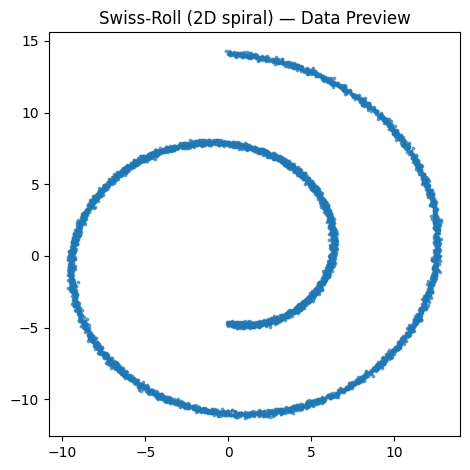

Config(steps=6000, lr=0.001, cd_steps=20, step_size=0.06, noise_scale=0.01, replay_ratio=0.95, buffer_size=80000, dim=2, hidden=128, l2=0.0001, energy_reg=0.0001, eval_every=500, grid_n=160, grid_lim=15.0)
[Train] starting...
[Iter 00001/6000] loss=-0.0234 e_pos=-0.0630 e_neg=-0.0349 | 29.2 it/s | ETA 3.4 min
[Iter 00500/6000] loss=-0.1395 e_pos=-4.2424 e_neg=-4.0931 | 37.3 it/s | ETA 2.5 min
[Iter 01000/6000] loss=-0.6168 e_pos=-6.1241 e_neg=-5.4976 | 32.1 it/s | ETA 2.6 min
[Iter 01500/6000] loss=-1.9468 e_pos=-15.1856 e_neg=-13.2291 | 30.8 it/s | ETA 2.4 min
[Iter 02000/6000] loss=-1.3809 e_pos=-23.4919 e_neg=-22.1011 | 29.7 it/s | ETA 2.2 min
[Iter 02500/6000] loss=-1.8653 e_pos=-38.1543 e_neg=-36.2790 | 29.4 it/s | ETA 2.0 min
[Iter 03000/6000] loss=-2.0046 e_pos=-53.7399 e_neg=-51.7255 | 30.5 it/s | ETA 1.6 min
[Iter 03500/6000] loss=-3.0873 e_pos=-74.4710 e_neg=-71.3741 | 30.6 it/s | ETA 1.4 min
[Iter 04000/6000] loss=-3.4696 e_pos=-97.6812 e_neg=-94.2019 | 30.2 it/s | ETA 1.1 m

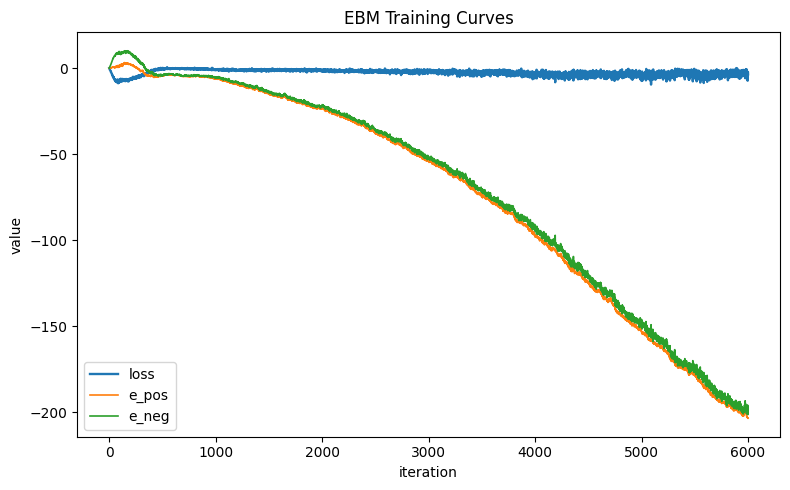

In [11]:
import math, time, random
from dataclasses import dataclass
import numpy as np
import torch
import torch.nn as nn
from torch import Tensor
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML, display

# ----------------------------
# 0) Reproducibility & Device
# ----------------------------
def set_seed(seed: int = 42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[Setup] device={device}, torch={torch.__version__}")

# -----------------------------------------
# 1) Data: Swiss-Roll (2D spiral variant)
# -----------------------------------------
def make_swiss_roll_2d(n_samples=60000, t_min=1.5*math.pi, t_max=4.5*math.pi, noise=0.10, seed=0):
    rng = np.random.default_rng(seed)
    t = rng.random(n_samples) * (t_max - t_min) + t_min
    r = t
    x = r * np.cos(t)
    y = r * np.sin(t)
    X = np.stack([x, y], axis=1).astype(np.float32)
    X += rng.standard_normal(X.shape).astype(np.float32) * noise
    idx = rng.permutation(n_samples)
    return X[idx]

X = make_swiss_roll_2d(n_samples=60000, noise=0.10, seed=0)
data = torch.from_numpy(X)
dataset = TensorDataset(data)

loader = DataLoader(
    dataset,
    batch_size=1024,
    shuffle=True,
    drop_last=True,
    num_workers=0,
    pin_memory=(device.type == "cuda")
)

# Data preview
plt.figure(figsize=(4.8,4.8))
plt.scatter(X[:6000,0], X[:6000,1], s=3, alpha=0.6)
plt.title("Swiss-Roll (2D spiral) — Data Preview")
plt.tight_layout(); plt.show()

# -----------------------------------------
# 2) EBM: Energy network E_theta(x)
# -----------------------------------------
class EnergyNet(nn.Module):
    def __init__(self, dim=2, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, 1)
        )
    def forward(self, x: Tensor) -> Tensor:
        return self.net(x).squeeze(1)

# -----------------------------------------
# 3) Langevin dynamics & utilities
# -----------------------------------------
def langevin_step(x: Tensor, energy_fn, step_size=0.06, noise_scale=0.01) -> Tensor:
    x = x.clone().detach().requires_grad_(True)
    with torch.enable_grad():
        e = energy_fn(x).sum()
        grad_x, = torch.autograd.grad(e, x, create_graph=False)
    x = x - 0.5 * step_size * grad_x + noise_scale * torch.randn_like(x)
    return x.detach()

def make_grid(xmin=-15, xmax=15, ymin=-15, ymax=15, n=160):
    xs = np.linspace(xmin, xmax, n)
    ys = np.linspace(ymin, ymax, n)
    Xg, Yg = np.meshgrid(xs, ys)
    grid = np.stack([Xg.flatten(), Yg.flatten()], axis=1).astype(np.float32)
    return xs, ys, grid

@torch.no_grad()
def compute_energy_grid(model, xmin=-15, xmax=15, ymin=-15, ymax=15, n=160):
    model.eval()
    xs, ys, grid = make_grid(xmin, xmax, ymin, ymax, n)
    g = torch.from_numpy(grid).to(device)
    e = model(g).cpu().numpy().reshape(n, n)
    return xs, ys, e

# -----------------------------------------
# 4) Config
# -----------------------------------------
@dataclass
class Config:
    steps:   int   = 6000
    lr:      float = 1e-3
    cd_steps:int   = 20
    step_size:float= 0.06
    noise_scale:float=0.01
    replay_ratio:float=0.95
    buffer_size:int = 80000
    dim:int          = 2
    hidden:int       = 128
    l2:float         = 1e-4
    energy_reg:float = 1e-4
    eval_every:int   = 500
    grid_n:int       = 160
    grid_lim:float   = 15.0

cfg = Config(); print(cfg)

# -----------------------------------------
# 5) Initialize model/optimizer/replay
# -----------------------------------------
model = EnergyNet(dim=cfg.dim, hidden=cfg.hidden).to(device)
opt = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.l2)

replay = torch.randn(cfg.buffer_size, cfg.dim)  # CPU buffer
replay_ptr = 0

def sample_negatives(batch_size: int) -> Tensor:
    global replay_ptr, replay
    use_replay = (np.random.rand(batch_size) < cfg.replay_ratio)
    x0 = torch.randn(batch_size, cfg.dim)
    idx = np.random.randint(0, replay.shape[0], size=batch_size)
    x_replay = replay[idx]
    x = torch.where(torch.tensor(use_replay)[:,None], x_replay, x0).to(device)
    for _ in range(cfg.cd_steps):
        x = langevin_step(x, model, step_size=cfg.step_size, noise_scale=cfg.noise_scale)
    with torch.no_grad():
        n = min(batch_size, replay.shape[0] - replay_ptr)
        replay[replay_ptr:replay_ptr+n] = x[:n].cpu()
        replay_ptr = (replay_ptr + n) % replay.shape[0]
    return x

# -----------------------------------------
# 6) Training
# -----------------------------------------
loss_hist, epos_hist, eneg_hist = [], [], []
frames_energy, frames_samples = [], []
t0 = time.time(); it = 0

print("[Train] starting...")
while it < cfg.steps:
    for (x_batch,) in loader:
        if it >= cfg.steps:
            break
        x_pos = x_batch.to(device)
        x_neg = sample_negatives(x_pos.size(0))

        e_pos = model(x_pos).mean()
        e_neg = model(x_neg).mean()
        loss = e_pos - e_neg + cfg.energy_reg * (x_pos.pow(2).mean() + x_neg.pow(2).mean())

        opt.zero_grad(set_to_none=True)
        loss.backward(); opt.step()

        loss_hist.append(loss.item())
        epos_hist.append(e_pos.item())
        eneg_hist.append(e_neg.item())
        it += 1

        if it % 500 == 0 or it == 1:
            elapsed = time.time()-t0
            rate = it/max(elapsed,1e-6)
            print(f"[Iter {it:05d}/{cfg.steps}] loss={loss.item():.4f} e_pos={e_pos.item():.4f} e_neg={e_neg.item():.4f} "
                  f"| {rate:.1f} it/s | ETA {(cfg.steps-it)/rate/60:.1f} min")

        if it % cfg.eval_every == 0 or it == 1:
            xs, ys, Z = compute_energy_grid(model, -cfg.grid_lim, cfg.grid_lim, -cfg.grid_lim, cfg.grid_lim, cfg.grid_n)
            frames_energy.append((xs, ys, Z))
            with torch.no_grad():
                frames_samples.append(sample_negatives(6000).cpu().numpy())

print(f"[Train] done in {(time.time()-t0)/60:.2f} min; frames={len(frames_energy)}")

# -----------------------------------------
# 7) Curves
# -----------------------------------------
iters = np.arange(1, len(loss_hist)+1)
plt.figure(figsize=(8,5))
plt.plot(iters, loss_hist, label="loss", linewidth=1.7)
plt.plot(iters, epos_hist, label="e_pos", linewidth=1.2)
plt.plot(iters, eneg_hist, label="e_neg", linewidth=1.2)
plt.xlabel("iteration"); plt.ylabel("value"); plt.title("EBM Training Curves")
plt.legend(); plt.tight_layout(); plt.show()

# -----------------------------------------
# 8) Animation (no extra static figure)
# -----------------------------------------
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10,4.5))

def init():
    ax0.clear(); ax1.clear()
    return []

def update(frame_idx):
    ax0.clear(); ax1.clear()
    xs, ys, Z = frames_energy[frame_idx]
    ax0.contourf(xs, ys, Z, levels=60)
    ax0.set_title(f"Energy Landscape (frame {frame_idx+1}/{len(frames_energy)})")
    ax0.set_aspect('equal', 'box')
    samples = frames_samples[frame_idx]
    ax1.scatter(samples[:,0], samples[:,1], s=3, alpha=0.6)
    ax1.set_title("Generated Samples")
    ax1.set_aspect('equal', 'box')
    return []

anim = animation.FuncAnimation(fig, update, init_func=init,
                               frames=len(frames_energy), interval=600, blit=False)

plt.close(fig)  # <-- prevent static plot display
display(HTML(anim.to_jshtml()))


# Score-Based Generative Models: From First Principles to Practical Training

## 1) Core Goal and Intuition

We want to learn to generate new samples that look like our data $\mathbf{x}\sim p_{\text{data}}$.  
Instead of modeling the (often intractable) density $p(\mathbf{x})$ directly, **score-based models** learn its **score function**:

$$
\textbf{score}(\mathbf{x}) \;=\; \nabla_{\mathbf{x}} \log p(\mathbf{x}).
$$

**Why scores (gradients of log-density)?**
- The score captures the **direction** in which density increases fastest. If we can estimate it, we can **walk along the gradient** from noise to data.
- Scores are **invariant** to unknown normalizing constants (they cancel in $\nabla \log$), so we can **learn on unnormalized models** (just like EBMs).  
- This leads to powerful samplers (reverse-time SDEs / annealed Langevin) that gradually **denoise** from pure noise to data. See the seminal tutorial and papers by Song & Ermon:  
  - **Denoising Score Matching (NCSN)** (NeurIPS 2019): [paper](https://arxiv.org/abs/1907.05600?utm_source=chatgpt.com)  
  - **Score-based Modeling via SDEs** (NeurIPS 2021): [paper](https://arxiv.org/abs/2011.13456?utm_source=chatgpt.com)

## 2) From Score Matching to Denoising Score Matching (DSM)

Direct **score matching** (Hyvärinen, 2005) minimizes the squared error to the true score:

$$
\min_\theta \; \mathbb{E}_{\mathbf{x}\sim p_{\text{data}}} 
\Big[ \big\| s_\theta(\mathbf{x}) - \nabla_{\mathbf{x}} \log p(\mathbf{x}) \big\|_2^2 \Big].
$$

**Why not do this directly?**  
Because $\nabla_{\mathbf{x}}\log p(\mathbf{x})$ is unknown. Hyvärinen showed one can avoid densities with integration by parts, but it requires second derivatives (Laplacian), which is heavy for deep nets.

**DSM trick (Vincent, 2011):** Corrupt clean data $\mathbf{x}$ with Gaussian noise at level $\sigma$:
- $\tilde{\mathbf{x}} = \mathbf{x} + \sigma \boldsymbol{\epsilon}$ with $\boldsymbol{\epsilon}\sim\mathcal{N}(\mathbf{0}, \mathbf{I})$.
- The **conditional score** of the corruption model is **known**:  
  $$
  \nabla_{\tilde{\mathbf{x}}}\log p(\tilde{\mathbf{x}}\mid \mathbf{x}) = -\frac{\tilde{\mathbf{x}} - \mathbf{x}}{\sigma^2}.
  $$
- The **marginal score** of the noisy distribution $p_\sigma(\tilde{\mathbf{x}}) = (p_{\text{data}} * \mathcal{N}(0,\sigma^2 \mathbf{I}))$ equals  
  $$
  \nabla_{\tilde{\mathbf{x}}}\log p_\sigma(\tilde{\mathbf{x}}) 
  = \mathbb{E}\!\left[ \nabla_{\tilde{\mathbf{x}}}\log p(\tilde{\mathbf{x}}\mid \mathbf{x}) \;\middle|\; \tilde{\mathbf{x}} \right].
  $$

So we train a **noise-conditional score network** $s_\theta(\tilde{\mathbf{x}}, \sigma)$ to match that target:

$$
\boxed{
\mathcal{L}_{\text{DSM}}(\theta)
= \mathbb{E}_{\mathbf{x}, \sigma, \boldsymbol{\epsilon}}
\Big[\lambda(\sigma)\,\big\| s_\theta(\mathbf{x}+\sigma\boldsymbol{\epsilon}, \sigma)
+ \tfrac{\boldsymbol{\epsilon}}{\sigma} \big\|_2^2\Big]
}
$$

**Why the weight $\lambda(\sigma)$?**  
Noisy levels contribute unequally; common choices are $\lambda(\sigma)=\sigma^2$ (balances SNR across scales) or $\lambda(\sigma)=1$ (simple). Using $\lambda(\sigma)=\sigma^2$ is standard in NCSN because the target magnitude scales like $1/\sigma$.

**Why multiple noise levels?**  
- Large $\sigma$ makes the distribution close to a Gaussian (easy to learn).  
- Small $\sigma$ captures fine details.  
We **anneal** from coarse $\rightarrow$ fine, hence “annealed Langevin dynamics”.

## 3) Noise-Conditional Score Networks (NCSN)

We approximate the multi-scale score with a single network:
- Input: the noisy point $\tilde{\mathbf{x}}$ and the noise level $\sigma$.  
- Output: the score estimate $s_\theta(\tilde{\mathbf{x}}, \sigma) \approx \nabla_{\tilde{\mathbf{x}}}\log p_\sigma(\tilde{\mathbf{x}})$.

**Design choices and why:**
- **Noise embedding:** feed $\log\sigma$ through a small MLP or sinusoidal/time embedding  
  → normalizes scale and gives the model a smooth notion of “time/noise”.  
- **Loss weighting $\lambda(\sigma)=\sigma^2$:** equalizes gradient magnitudes across noise levels.  
- **Geometric $\sigma$ schedule** from $\sigma_{\max}$ to $\sigma_{\min}$:  
  → covers many scales efficiently; multiplicative steps preserve SNR ratios.  
- **Data standardization** (zero-mean/unit-var):  
  → simplifies scale for both $\sigma$ and network.

## 4) Sampling with Annealed Langevin Dynamics (ALD)

After training $s_\theta$, we **sample** by progressively denoising:
1. Start from $\mathbf{x}_T \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ at large noise $\sigma_{\max}$.  
2. For each noise level $\sigma_t \searrow \sigma_{\min}$, do $K$ **Langevin steps**:

$$
\mathbf{x} \leftarrow \mathbf{x} + \eta_t\, s_\theta(\mathbf{x}, \sigma_t) + \sqrt{2\eta_t}\,\boldsymbol{\xi}, 
\qquad \boldsymbol{\xi}\sim\mathcal{N}(\mathbf{0},\mathbf{I}).
$$

**Why this form?**  
- Langevin uses the **score** as drift (gradient ascent on $\log p_\sigma$).  
- The **noise term** avoids mode collapse and approximates samples from $p_\sigma$.  
- Annealing $\sigma$ gradually sharpens the distribution until we reach data scale.

**Choice of $\eta_t$ (step size):**  
- Larger at high noise (coarse moves), smaller at low noise (fine details).  
- Practical heuristic: $\eta_t \propto \sigma_t^2$ or tuned per-level.

## 5) SDE View: VP/VE SDEs, Reverse-Time SDE, and ODE Samplers

Score-based modeling can be framed in **continuous time** via **SDEs** that transform data into noise and back.

Two canonical forward SDEs:

- **Variance-Exploding (VE)** SDE (adds noise; variance increases):
  $$
  d\mathbf{x} = \sqrt{\frac{d[\sigma^2(t)]}{dt}}\, d\mathbf{w},
  $$
  where $\mathbf{w}$ is standard Brownian motion. This generalizes the DSM multi-sigma setup.

- **Variance-Preserving (VP)** SDE (DDPM-like; multiplicative noise/decay):
  $$
  d\mathbf{x} = -\tfrac{1}{2}\beta(t)\,\mathbf{x}\,dt + \sqrt{\beta(t)}\, d\mathbf{w}.
  $$
  Discretizing this SDE yields the classic DDPM forward noising process  
  (Ho et al., 2020: [paper](https://arxiv.org/abs/2006.11239?utm_source=chatgpt.com)).

**Reverse-time SDE** (Anderson, 1982; Song et al., 2021):  
Given the forward SDE $d\mathbf{x} = f(\mathbf{x},t)\,dt + g(t)\,d\mathbf{w}$, the **reverse** is

$$
d\mathbf{x} = \big[f(\mathbf{x},t) - g(t)^2 \nabla_{\mathbf{x}} \log p_t(\mathbf{x})\big]\,dt + g(t)\, d\bar{\mathbf{w}}.
$$

**Why do we need the score here?**  
Because the drift of the **reverse process** depends on $\nabla_{\mathbf{x}}\log p_t(\mathbf{x})$, which we approximate with our trained $s_\theta(\mathbf{x}, t)$.

**Probability-flow ODE** (deterministic sampler):

$$
\frac{d\mathbf{x}}{dt} = f(\mathbf{x},t) - \tfrac{1}{2} g(t)^2 \nabla_{\mathbf{x}}\log p_t(\mathbf{x}).
$$

- **Why ODE samplers?** They **share marginals** with the SDE (same $p_t$), but have **no noise**.  
- **Bonus:** With the ODE, you can compute **log-likelihoods** via instantaneous change of variables (Neural ODE trick).

**Predictor–Corrector (PC) samplers:**  
Alternate a reverse-SDE **predictor** step with a few **Langevin (corrector)** steps using the score → **better sample quality**, especially at low noise.

## 6) Relation to Diffusion Models and EBMs

- **Diffusion models** (DDPM/Score-SDEs) are two views of the **same family**:  
  - **DDPM** maximizes a **variational lower bound (ELBO)** with a discrete noise schedule.  
  - **Score-SDE** learns continuous-time scores and samples via reverse-SDE/ODE.  
  Both rely on **score estimation** at varying noise levels.
- **EBM connection:** Since the score equals $-\nabla_{\mathbf{x}}E(\mathbf{x})$ for some energy, score models can be seen as **EBMs whose score we learn directly** (no partition function).  
- **Why score models often train more stably than EBMs?**  
  We avoid normalizing constants and sample from **known Gaussians during training** (the corrupted marginals), rather than from the **learned** model itself.

Useful resources:  
- **Score SDEs** (Song et al., 2021): [paper](https://arxiv.org/abs/2011.13456?utm_source=chatgpt.com) and [code](https://github.com/yang-song/score_sde_pytorch?utm_source=chatgpt.com).  
- **DDPM** (Ho et al., 2020): [paper](https://arxiv.org/abs/2006.11239?utm_source=chatgpt.com).  
- **EDM** (Karras et al., 2022): [paper](https://arxiv.org/abs/2206.00364?utm_source=chatgpt.com) for practical noise parameterization/schedules.

## 7) Design Choices (and Why)

1. **Noise schedule $\{\sigma_t\}_{t=T\to 0}$ (VE) or $\{\beta(t)\}$ (VP):**  
   - Start **large** (easy, near-Gaussian), end **small** (details).  
   - **Geometric** decay often balances coverage and efficiency.

2. **Loss weighting $\lambda(\sigma)$:**  
   - $\lambda(\sigma)=\sigma^2$ gives similar gradient magnitudes across scales; prevents the loss from being dominated by the smallest $\sigma$.

3. **Network inputs:**  
   - Provide **log-$\sigma$ embedding** so the network knows the noise level smoothly.  
   - Normalize data so scales are consistent across $\sigma$.

4. **Sampler hyperparameters (ALD/PC):**  
   - **Step size $\eta_t$** proportional to $\sigma_t^2$ works well.  
   - **Corrector steps** (few Langevin steps per level) improve quality near small $\sigma$.

5. **EMA of weights:**  
   - An **Exponential Moving Average** of parameters stabilizes sampling at test time (commonly used in diffusion implementations).

6. **Clipping / gradient norms:**  
   - Prevent rare large gradients at very small $\sigma$ from destabilizing training.

## 8) What We Will Implement on Swiss-Roll (2D)

We’ll implement a compact **VE-style** score model with **Denoising Score Matching**:

- **Training:**
  - Dataset: 2D Swiss-roll (spiral).  
  - Noise levels: geometric schedule $\sigma_{\max}\rightarrow\sigma_{\min}$.  
  - Loss: DSM with $\lambda(\sigma)=\sigma^2$.  
  - Architecture: small MLP with a **log-$\sigma$ embedding**.

- **Sampling:**
  - **Annealed Langevin Dynamics (ALD)** across the same schedule.  
  - **Animation:** left = evolving energy/score field as a colored contour (proxy via scalar potential from the learned score); right = generated samples.

**What to expect:**  
- Early frames: samples look Gaussian; the score field is weak/blurred.  
- Middle: scores begin forming **tangential flows** toward the spiral manifold.  
- Late: samples concentrate along the Swiss-roll’s winding curve.

## 9) Connections to Likelihood and Evaluation

- With the **probability-flow ODE**, we can (in principle) compute **exact likelihoods** using the instantaneous change of variables formula (Neural ODE log-det trick).  
- In 2D Swiss-roll demos, qualitative inspection (animations) + simple metrics (e.g., 2D KDE comparisons) are usually sufficient.

## 10) TL;DR

- **Train** a noise-conditional score $s_\theta(\tilde{\mathbf{x}},\sigma)$ using **DSM**.  
- **Sample** by gradually **denoising** via **ALD** or integrating a **reverse SDE/ODE**.  
- **Why it works:** scores encode where density increases; following them from noise to data reconstructs the data manifold.

**Next**: we’ll write the **PyTorch implementation** for Swiss-Roll with DSM training and an **inline matplotlib animation** (left: learned field/energy proxy, right: samples).


[Setup] device=cuda, torch=2.7.1+cu126


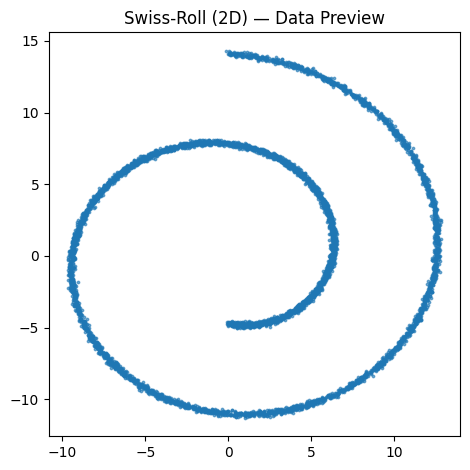

Config(steps=12000, lr=0.002, batch_size=1024, sigma_min=0.02, sigma_max=2.5, sigma_levels=14, dsm_weight='sigma2', eval_every=1000, hidden=512, depth=6, embed_dim=128, grid_lim=15.0, grid_n=128, proxy_steps=24, ald_steps_per_level=50, ald_step_coeff=0.12, n_gen=5000, ema_decay=0.9995)
[Train] starting...
[Iter 00001/12000] loss=9.2701 | 23.0 it/s | ETA 8.7 min
[Iter 00400/12000] loss=1.6470 | 25.3 it/s | ETA 7.6 min
[Iter 00800/12000] loss=1.5240 | 28.1 it/s | ETA 6.6 min
[Iter 01200/12000] loss=1.5241 | 26.9 it/s | ETA 6.7 min
[Iter 01600/12000] loss=1.4140 | 28.2 it/s | ETA 6.2 min
[Iter 02000/12000] loss=1.4613 | 28.8 it/s | ETA 5.8 min
[Iter 02400/12000] loss=1.4188 | 28.1 it/s | ETA 5.7 min
[Iter 02800/12000] loss=1.4394 | 29.5 it/s | ETA 5.2 min
[Iter 03200/12000] loss=1.4061 | 30.6 it/s | ETA 4.8 min
[Iter 03600/12000] loss=1.4175 | 30.7 it/s | ETA 4.6 min
[Iter 04000/12000] loss=1.2987 | 31.0 it/s | ETA 4.3 min
[Iter 04400/12000] loss=1.4925 | 30.3 it/s | ETA 4.2 min
[Iter 048

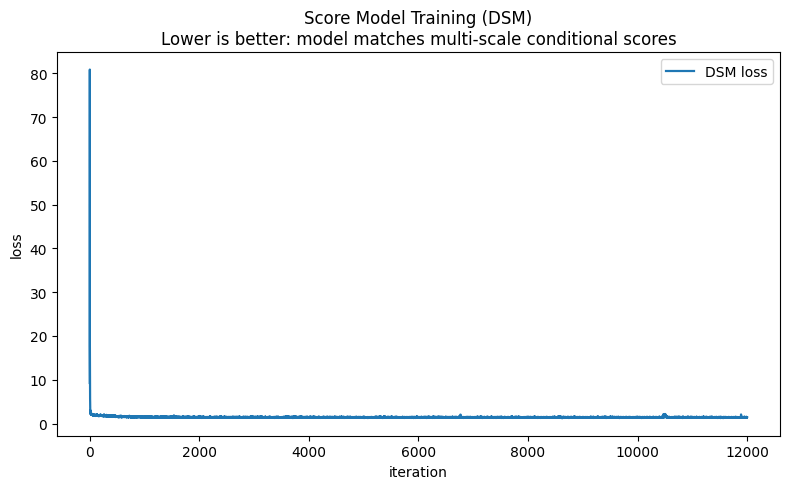

In [13]:
# ================================================================
# Stronger Score-Based Model (DSM + VE) on 2D Swiss-Roll
# - Wider+deeper residual MLP with FiLM conditioning by log-sigma
# - EMA for stabler snapshots
# - Inline progress logs, curves, and a clear, annotated animation:
#     Left: score-derived potential proxy (blue = lower ≈ more likely)
#     Right: ALD generated samples overlaid on data backdrop
# ================================================================

import math, time, random
from dataclasses import dataclass
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch import Tensor

import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML, display

# ----------------------------
# 0) Reproducibility & Device
# ----------------------------
def set_seed(seed: int = 42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[Setup] device={device}, torch={torch.__version__}")

# -----------------------------------------
# 1) Data: Swiss-Roll (2D spiral)
# -----------------------------------------
def make_swiss_roll_2d(n_samples=60000, t_min=1.5*math.pi, t_max=4.5*math.pi, noise=0.10, seed=0):
    rng = np.random.default_rng(seed)
    t = rng.random(n_samples) * (t_max - t_min) + t_min
    r = t
    x = r * np.cos(t)
    y = r * np.sin(t)
    X = np.stack([x, y], axis=1).astype(np.float32)
    X += rng.standard_normal(X.shape).astype(np.float32) * noise
    idx = rng.permutation(n_samples)
    return X[idx]

X = make_swiss_roll_2d(n_samples=60000, noise=0.10, seed=0)
dataset = TensorDataset(torch.from_numpy(X))
loader = DataLoader(
    dataset,
    batch_size=1024,
    shuffle=True,
    drop_last=True,
    num_workers=0,
    pin_memory=(device.type == "cuda")
)

# Quick preview
plt.figure(figsize=(4.8,4.8))
plt.scatter(X[:6000,0], X[:6000,1], s=3, alpha=0.6)
plt.title("Swiss-Roll (2D) — Data Preview")
plt.tight_layout(); plt.show()

# -----------------------------------------
# 2) Config & helpers
# -----------------------------------------
@dataclass
class Config:
    steps: int = 12000                # training iterations
    lr: float = 2e-3                  # a bit higher for wider net
    batch_size: int = 1024
    sigma_min: float = 0.02
    sigma_max: float = 2.5
    sigma_levels: int = 14            # sampling schedule depth
    dsm_weight: str = "sigma2"        # "sigma2" or "1"
    eval_every: int = 1000            # capture frames
    hidden: int = 512                 # wider
    depth: int = 6                    # deeper
    embed_dim: int = 128              # stronger time embedding
    grid_lim: float = 15.0
    grid_n: int = 128                 # viz grid
    proxy_steps: int = 24             # line-integral steps (potential proxy)
    ald_steps_per_level: int = 50     # ALD steps per sigma
    ald_step_coeff: float = 0.12      # eta_t = coeff * sigma^2
    n_gen: int = 5000                 # samples per frame
    ema_decay: float = 0.9995         # stronger EMA

cfg = Config(); print(cfg)

def geometric_sigmas(n, sigma_min, sigma_max):
    return sigma_max * (sigma_min / sigma_max) ** (torch.linspace(0, 1, n))

# -----------------------------------------
# 3) Stronger Noise-Conditional Score Net
# -----------------------------------------
class TimeEmbed(nn.Module):
    """Embed log-sigma with a small MLP."""
    def __init__(self, embed_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, embed_dim), nn.SiLU(),
            nn.Linear(embed_dim, embed_dim), nn.SiLU()
        )
    def forward(self, log_sigma: Tensor) -> Tensor:
        return self.net(log_sigma)

class ResFiLMBlock(nn.Module):
    """
    Residual MLP block with FiLM conditioning from time embedding.
    h <- h + F( LayerNorm(h) -> SiLU -> (gamma*h + beta) -> Linear )
    """
    def __init__(self, width: int, temb_dim: int):
        super().__init__()
        self.ln = nn.LayerNorm(width)
        self.fc1 = nn.Linear(width, width)
        self.fc2 = nn.Linear(width, width)
        self.gamma = nn.Linear(temb_dim, width)
        self.beta  = nn.Linear(temb_dim, width)

    def forward(self, h: Tensor, temb: Tensor) -> Tensor:
        x = self.ln(h)
        # FiLM: scale & shift from time embedding
        g = torch.tanh(self.gamma(temb))
        b = self.beta(temb)
        x = x * (1.0 + g) + b
        x = F.silu(self.fc1(x))
        x = self.fc2(x)
        return h + x  # residual

class ScoreNet(nn.Module):
    def __init__(self, hidden=512, depth=6, embed_dim=128):
        super().__init__()
        self.temb = TimeEmbed(embed_dim)
        self.inp = nn.Linear(2, hidden)
        self.blocks = nn.ModuleList([ResFiLMBlock(hidden, embed_dim) for _ in range(depth)])
        self.out = nn.Sequential(
            nn.SiLU(),
            nn.Linear(hidden, 2)
        )
    def forward(self, x: Tensor, sigma: Tensor) -> Tensor:
        log_sigma = torch.log(sigma)
        te = self.temb(log_sigma)              # (B, embed_dim)
        h = F.silu(self.inp(x))                # (B, hidden)
        for blk in self.blocks:
            h = blk(h, te)
        return self.out(h)                     # (B, 2)

# EMA wrapper
class EMA:
    def __init__(self, model, decay=0.9995):
        self.decay = decay
        self.shadow = [p.clone().detach() for p in model.parameters() if p.requires_grad]
        self.params = [p for p in model.parameters() if p.requires_grad]
    @torch.no_grad()
    def update(self):
        for s, p in zip(self.shadow, self.params):
            s.mul_(self.decay).add_(p, alpha=1.0 - self.decay)
    @torch.no_grad()
    def store(self):
        self.backup = [p.clone() for p in self.params]
    @torch.no_grad()
    def copy_to(self):
        for p, s in zip(self.params, self.shadow):
            p.data.copy_(s.data)
    @torch.no_grad()
    def restore(self):
        for p, b in zip(self.params, self.backup):
            p.data.copy_(b.data)

score_model = ScoreNet(hidden=cfg.hidden, depth=cfg.depth, embed_dim=cfg.embed_dim).to(device)
opt = torch.optim.AdamW(score_model.parameters(), lr=cfg.lr, weight_decay=1e-4)
ema = EMA(score_model, decay=cfg.ema_decay)

# -----------------------------------------
# 4) DSM loss (multi-sigma)
# -----------------------------------------
def dsm_loss(model, x: Tensor) -> Tensor:
    B = x.size(0)
    # sample log-uniform sigmas
    u = torch.rand(B, 1, device=x.device)
    sigmas = cfg.sigma_min * (cfg.sigma_max / cfg.sigma_min) ** u
    eps = torch.randn_like(x)
    xt = x + sigmas * eps
    s = model(xt, sigmas)
    target = -eps / sigmas
    w = (sigmas**2) if cfg.dsm_weight == "sigma2" else torch.ones_like(sigmas)
    return (w * (s - target)**2).sum(dim=1).mean()

# -----------------------------------------
# 5) Visualization: score-derived potential proxy
# -----------------------------------------
@torch.no_grad()
def score_potential_proxy(model, xmin, xmax, ymin, ymax, n=128, steps=24, sigma_eval=0.08):
    xs = np.linspace(xmin, xmax, n)
    ys = np.linspace(ymin, ymax, n)
    Xg, Yg = np.meshgrid(xs, ys)
    grid = np.stack([Xg.flatten(), Yg.flatten()], axis=1).astype(np.float32)
    g = torch.from_numpy(grid).to(device)

    t = torch.linspace(0.0, 1.0, steps, device=device).view(steps, 1, 1)
    pts = t * g.unsqueeze(0)                     # (steps, N, 2)

    chunk = 20000
    vals = []
    for i in range(0, pts.size(1), chunk):
        pchunk = pts[:, i:i+chunk, :]
        m = pchunk.size(1)
        sig_chunk = torch.full((steps*m, 1), sigma_eval, device=device)
        x_in = pchunk.reshape(steps*m, 2)
        s = model(x_in, sig_chunk).reshape(steps, m, 2)
        dot = (s * g[i:i+chunk].unsqueeze(0)).sum(dim=2)  # s(τx)·x
        integ = dot.mean(dim=0)
        vals.append((-integ).detach().cpu().numpy())      # negative → “energy-like”
    phi = np.concatenate(vals, axis=0).reshape(n, n)
    return xs, ys, phi

# -----------------------------------------
# 6) Annealed Langevin Dynamics (ALD) sampler
# -----------------------------------------
@torch.no_grad()
def ald_sample(model, n_samples=5000, sigmas=None, steps_per_level=50, step_coeff=0.12):
    if sigmas is None:
        sigmas = geometric_sigmas(cfg.sigma_levels, cfg.sigma_min, cfg.sigma_max).flip(0)
    x = torch.randn(n_samples, 2, device=device)
    for sigma in sigmas:
        sigma = sigma.to(device)
        eta = step_coeff * (sigma**2)
        for _ in range(steps_per_level):
            s = model(x, torch.full((n_samples,1), float(sigma.item()), device=device))
            x = x + eta * s + torch.randn_like(x) * math.sqrt(2*eta)
    return x.detach().cpu().numpy()

# -----------------------------------------
# 7) Training loop
# -----------------------------------------
loss_hist = []
frames_potential, frames_samples = [], []

print("[Train] starting...")
t0 = time.time(); it = 0
score_model.train()

while it < cfg.steps:
    for (xb,) in loader:
        if it >= cfg.steps:
            break
        x = xb.to(device, non_blocking=(device.type=="cuda"))
        loss = dsm_loss(score_model, x)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(score_model.parameters(), max_norm=2.0)
        opt.step()
        ema.update()

        loss_hist.append(loss.item())
        it += 1

        # progress
        if it % 400 == 0 or it == 1:
            elapsed = time.time() - t0
            rate = it / max(elapsed, 1e-6)
            eta_min = (cfg.steps - it) / max(rate, 1e-6) / 60
            print(f"[Iter {it:05d}/{cfg.steps}] loss={loss.item():.4f} | {rate:.1f} it/s | ETA {eta_min:.1f} min")

        # evaluation snapshots for animation
        if it % cfg.eval_every == 0 or it == 1:
            ema.store(); ema.copy_to()
            score_model.eval()
            xs, ys, phi = score_potential_proxy(
                score_model,
                xmin=-cfg.grid_lim, xmax=cfg.grid_lim,
                ymin=-cfg.grid_lim, ymax=cfg.grid_lim,
                n=cfg.grid_n, steps=cfg.proxy_steps, sigma_eval=0.08
            )
            samps = ald_sample(
                score_model,
                n_samples=cfg.n_gen,
                sigmas=geometric_sigmas(cfg.sigma_levels, cfg.sigma_min, cfg.sigma_max).flip(0),
                steps_per_level=cfg.ald_steps_per_level,
                step_coeff=cfg.ald_step_coeff
            )
            frames_potential.append((xs, ys, phi))
            frames_samples.append(samps)
            ema.restore()
            score_model.train()

print(f"[Train] done in {(time.time()-t0)/60:.2f} min; frames={len(frames_potential)}")

# -----------------------------------------
# 8) Training curve with interpretation
# -----------------------------------------
plt.figure(figsize=(8,5))
plt.plot(np.arange(1, len(loss_hist)+1), loss_hist, label="DSM loss", linewidth=1.6)
plt.xlabel("iteration"); plt.ylabel("loss")
plt.title("Score Model Training (DSM)\nLower is better: model matches multi-scale conditional scores")
plt.legend(); plt.tight_layout(); plt.show()

# -----------------------------------------
# 9) Animation with clear, instructive labels
# -----------------------------------------
# Compute a global color scale for stability across frames
phi_min = min(phi.min() for (_, _, phi) in frames_potential)
phi_max = max(phi.max() for (_, _, phi) in frames_potential)

# Pre-sample a data backdrop for context on right subplot
backdrop = X[np.random.choice(len(X), size=6000, replace=False)]

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 5))

def init():
    ax0.clear(); ax1.clear()
    return []

def update(i):
    ax0.clear(); ax1.clear()
    xs, ys, phi = frames_potential[i]
    im = ax0.contourf(xs, ys, phi, levels=60, vmin=phi_min, vmax=phi_max, cmap="viridis")
    # colorbar (create once and update mappable)
    if i == 0:
        cbar = fig.colorbar(im, ax=ax0, fraction=0.046, pad=0.04)
        cbar.set_label("Potential proxy  (lower ≈ more likely)", rotation=90)
    ax0.set_title(f"Score-Derived Potential — Frame {i+1}/{len(frames_potential)}\n"
                  f"Blue = lower potential ≈ higher modeled probability")
    ax0.set_aspect('equal', 'box')

    # Right: ALD generated samples + faint data for reference
    ax1.scatter(backdrop[:,0], backdrop[:,1], s=2, alpha=0.12, color="gray", label="Data (backdrop)")
    samples = frames_samples[i]
    ax1.scatter(samples[:,0], samples[:,1], s=3, alpha=0.8, label="Generated (ALD)")
    ax1.set_title("Generated Samples (ALD)\nShould align with the Swiss-roll spiral")
    ax1.legend(loc="upper right", frameon=True, fontsize=8)
    ax1.set_aspect('equal', 'box')
    return []

anim = animation.FuncAnimation(fig, update, init_func=init,
                               frames=len(frames_potential), interval=600, blit=False)

plt.close(fig)  # prevent extra static figure
display(HTML(anim.to_jshtml()))